# Traffic Demand Prediction - CatBoost Baseline

## Objective
Predict the continuous target variable `demand` for the test dataset.

## Approach
1. Load training and test data
2. Perform exploratory data analysis
3. Handle missing values
4. Encode categorical features using CatBoost native handling
5. Train CatBoostRegressor
6. Evaluate using R² on validation split
7. Retrain on full training data
8. Generate competition submission file

## Model
CatBoostRegressor

## Validation Performance
- RMSE: 0.03437
- R²: 0.94

## Submission File
submission_catboost_baseline.csv

# 1. Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train_data = pd.read_csv('/content/drive/MyDrive/flipkartGridlock2.0/dataset/train.csv')
test_data = pd.read_csv('/content/drive/MyDrive/flipkartGridlock2.0/dataset/test.csv')
sample_submission_data = pd.read_csv('/content/drive/MyDrive/flipkartGridlock2.0/dataset/sample_submission.csv')

# 3. Exploratory Data Analysis

In [ ]:
train_data.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


In [ ]:
test_data.head()

,Index,geohash,day,timestamp,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,49,2:15,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02z9,49,2:15,Residential,1,Not Allowed,No,6.476213,Snowy
2,2,qp02yf,49,2:15,Residential,3,Allowed,Yes,22.318203,Sunny
3,3,qp02z6,49,2:15,Residential,2,Not Allowed,Yes,NaN,Rainy
4,4,qp02zd,49,2:15,Residential,1,Not Allowed,No,18.266162,Foggy


In [ ]:
train_data.shape
# Inspect dataset dimensions to understand
# sample size and feature count.

(77299, 11)

In [ ]:
test_data.shape

(41778, 10)

In [ ]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          77299 non-null  int64  
 1   geohash        77299 non-null  object 
 2   day            77299 non-null  int64  
 3   timestamp      77299 non-null  object 
 4   demand         77299 non-null  float64
 5   RoadType       76699 non-null  object 
 6   NumberofLanes  77299 non-null  int64  
 7   LargeVehicles  77299 non-null  object 
 8   Landmarks      77299 non-null  object 
 9   Temperature    74804 non-null  float64
 10  Weather        76502 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 6.5+ MB


In [ ]:
# numerical -> day, demand, NumberofLanes, Temperature
# categorical -> geohash, timestamp, RoadType, LargeVehicles, Landmarks, Weather
# id's -> Index
# missing values in RoadType, Temperature and Weather

In [ ]:
train_data.describe()

,Index,day,demand,NumberofLanes,Temperature
count,77299.000000,77299.000000,7.729900e+04,77299.000000,74804.000000
mean,38649.000000,48.101838,9.394238e-02,2.014334,16.405354
std,22314.443566,0.302438,1.421905e-01,0.904665,7.359835
min,0.000000,48.000000,6.245650e-07,1.000000,-14.935097
25%,19324.500000,48.000000,1.822723e-02,1.000000,11.430473
50%,38649.000000,48.000000,4.775994e-02,2.000000,16.382587
75%,57973.500000,48.000000,1.085951e-01,3.000000,21.298833
max,77298.000000,49.000000,1.000000e+00,5.000000,48.251433


# 4. Missing Value Analysis

In [ ]:
train_data.isnull().sum() # missing values

,0
Index,0
geohash,0
day,0
timestamp,0
demand,0
RoadType,600
NumberofLanes,0
LargeVehicles,0
Landmarks,0
Temperature,2495


In [ ]:
missing = train_data.isnull().mean()*100

In [ ]:
missing

,0
Index,0.000000
geohash,0.000000
day,0.000000
timestamp,0.000000
demand,0.000000
RoadType,0.776207
NumberofLanes,0.000000
LargeVehicles,0.000000
Landmarks,0.000000
Temperature,3.227726


In [ ]:
# The target distribution is positively skewed,
# indicating that low-demand observations occur
# more frequently than high-demand observations.

In [ ]:
train_data['RoadType'].value_counts()

,count
RoadType,
Residential,69230
Street,3909
Highway,3560


In [ ]:
train_data['Weather'].value_counts()

,count
Weather,
Sunny,27717
Rainy,20824
Foggy,20243
Snowy,7718


In [ ]:
train_data['day'].value_counts()

,count
day,
48,69427
49,7872


In [ ]:
train_data['NumberofLanes'].value_counts()

,count
NumberofLanes,
1,27411
2,24127
3,23919
4,926
5,916


In [ ]:
train_data['geohash'].value_counts()

,count
geohash,
qp03wd,105
qp03wf,105
qp09t0,105
qp03w9,105
qp03x3,105
...,...
qp08gs,1
qp08fq,1
qp0d1t,1


In [ ]:
train_data['LargeVehicles'].value_counts()

,count
LargeVehicles,
Not Allowed,50673
Allowed,26626


In [ ]:
train_data['Landmarks'].value_counts()

,count
Landmarks,
Yes,52042
No,25257


In [ ]:
train_data['timestamp'].value_counts()

,count
timestamp,
2:0,1778
1:45,1755
1:30,1750
1:15,1698
1:0,1668
...,...
19:30,308
18:30,303
18:45,297


In [ ]:
train_data.groupby('timestamp')['demand'].mean() # does demand change throughout the day

,demand
timestamp,
0:0,0.081056
0:15,0.081929
0:30,0.084357
0:45,0.085994
10:0,0.110319
...,...
8:45,0.105793
9:0,0.107004
9:15,0.112049


In [ ]:
train_data.nunique() # cardinaltiy
# high cardinality -> bad candidate for one-hot encoding

,0
Index,77299
geohash,1249
day,2
timestamp,96
demand,76715
RoadType,3
NumberofLanes,5
LargeVehicles,2
Landmarks,2
Temperature,74804


In [ ]:
corr = train_data.corr(numeric_only=True) # correlation matrix

In [ ]:
corr['demand'].sort_values()

,demand
Index,-0.001481
Temperature,0.003144
day,0.026807
NumberofLanes,0.214148
demand,1.000000


In [ ]:
# positive: Temperature, day, NumberofLanes -> they increase so demand increase

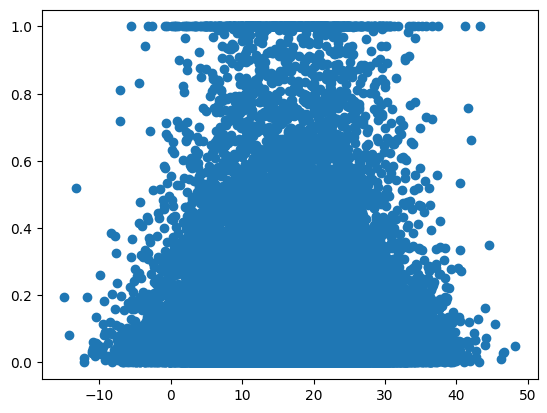

In [ ]:
# feature relationships
plt.scatter(train_data['Temperature'], train_data['demand']) # non-linear

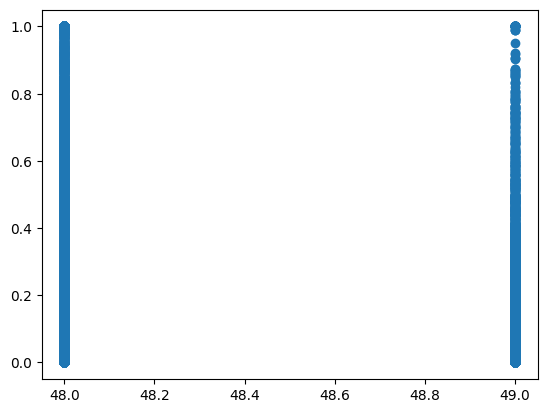

In [ ]:
plt.scatter(train_data['day'], train_data['demand']) # non-linear

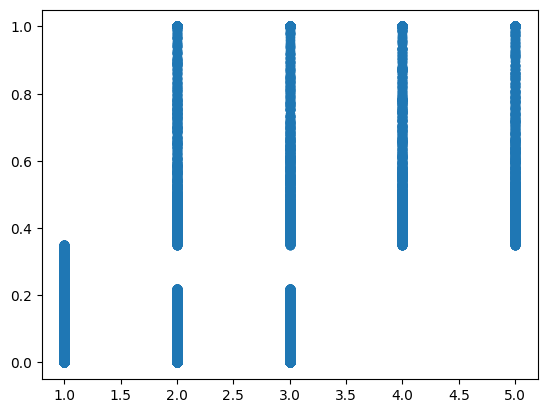

In [ ]:
plt.scatter(train_data['NumberofLanes'], train_data['demand']) # non-linear

In [ ]:
train_data.groupby('Weather')['demand'].mean()

,demand
Weather,
Foggy,0.093372
Rainy,0.094471
Snowy,0.092581
Sunny,0.094247


In [ ]:
# detecting outliers

{'whiskers': [<matplotlib.lines.Line2D at 0x7eff1613bb30>,
 'caps': [<matplotlib.lines.Line2D at 0x7eff1616c110>,
 'boxes': [<matplotlib.lines.Line2D at 0x7eff1613b620>],
 'medians': [<matplotlib.lines.Line2D at 0x7eff1616c740>],
 'fliers': [<matplotlib.lines.Line2D at 0x7eff1616ca10>],
 'means': []}

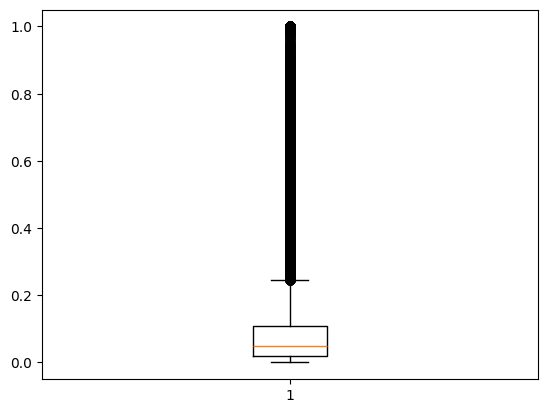

In [ ]:
plt.boxplot(train_data['demand'])

# 5. Feature Engineering

In [ ]:
# splitting hour and min

train_data[['hour', 'minute']] = train_data['timestamp'].str.split(':', expand=True)
train_data['hour'] = train_data['hour'].astype(int)
train_data['minute'] = train_data['minute'].astype(int)

test_data[['hour', 'minute']] = test_data['timestamp'].str.split(':', expand=True)
test_data['hour'] = test_data['hour'].astype(int)
test_data['minute'] = test_data['minute'].astype(int)

In [ ]:
train_data['time_slot'] = train_data['hour']*4+train_data['minute']//15
test_data['time_slot'] = test_data['hour']*4+test_data['minute']//15

In [ ]:
train_data['is_peak_hour'] = train_data['hour'].isin(
    [7, 8, 9, 17, 18, 19]
).astype(int)

test_data['is_peak_hour'] = test_data['hour'].isin(
    [7, 8, 9, 17, 18, 19]
).astype(int)

In [ ]:
train_data['timestamp'].nunique()

96

In [ ]:
sorted(train_data['timestamp'].unique())[:20]

['0:0',
 '0:15',
 '0:30',
 '0:45',
 '10:0',
 '10:15',
 '10:30',
 '10:45',
 '11:0',
 '11:15',
 '11:30',
 '11:45',
 '12:0',
 '12:15',
 '12:30',
 '12:45',
 '13:0',
 '13:15',
 '13:30',
 '13:45']

In [ ]:
train_data.drop(columns='timestamp', inplace=True)
test_data.drop(columns='timestamp', inplace=True)

In [ ]:
train_data.shape

(77299, 14)

## Why CatBoost?

- Handles categorical features natively
- Requires minimal preprocessing
- Robust to missing values
- Strong performance on tabular datasets
- Reduces risk of target leakage during encoding

In [ ]:
# training base model -> CatBoostRegressor

In [ ]:
# telling CatBoost which columns are categorical
categorical_features = [
    "geohash",
    "RoadType",
    "LargeVehicles",
    "Landmarks",
    "Weather"
]

In [ ]:
for col in categorical_features:
    train_data[col] = train_data[col].fillna("Missing").astype(str)
    test_data[col] = test_data[col].fillna("Missing").astype(str)

# 6. Train-Validation Split

In [ ]:
# Create a holdout validation set to estimate
# model performance on unseen data.

In [ ]:
# validation split
from sklearn.model_selection import train_test_split

In [ ]:
X = train_data.drop(columns=['demand', 'Index'])
y = train_data['demand']

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 7. Model Training

In [ ]:
# training baseline CatBoost
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.9 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostRegressor

In [ ]:
model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.03,
    depth=8,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    early_stopping_rounds=200,
    verbose=100
)

In [ ]:
model.fit(
    X_train,
    y_train,
    cat_features=categorical_features,
    eval_set=(X_valid, y_valid),
    use_best_model=True
)

0:	learn: 0.1389999	test: 0.1390171	best: 0.1390171 (0)	total: 175ms	remaining: 5m 49s
100:	learn: 0.0489897	test: 0.0479870	best: 0.0479870 (100)	total: 6.75s	remaining: 2m 6s
200:	learn: 0.0443041	test: 0.0440119	best: 0.0440119 (200)	total: 11.9s	remaining: 1m 46s
300:	learn: 0.0414562	test: 0.0415885	best: 0.0415885 (300)	total: 17.4s	remaining: 1m 38s
400:	learn: 0.0396711	test: 0.0400807	best: 0.0400807 (400)	total: 24.4s	remaining: 1m 37s
500:	learn: 0.0384787	test: 0.0391664	best: 0.0391664 (500)	total: 29.3s	remaining: 1m 27s
600:	learn: 0.0375486	test: 0.0385060	best: 0.0385056 (599)	total: 36.6s	remaining: 1m 25s
700:	learn: 0.0367161	test: 0.0378878	best: 0.0378878 (700)	total: 41.8s	remaining: 1m 17s
800:	learn: 0.0359170	test: 0.0373662	best: 0.0373662 (800)	total: 47.3s	remaining: 1m 10s
900:	learn: 0.0352905	test: 0.0370711	best: 0.0370711 (900)	total: 54.3s	remaining: 1m 6s
1000:	learn: 0.0347407	test: 0.0367737	best: 0.0367737 (1000)	total: 59.4s	remaining: 59.3s
1100

CatBoostRegressor(depth=8, early_stopping_rounds=200, eval_metric='RMSE', iterations=2000, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=100)

# 8. Validation Evaluation

In [1]:
# Evaluate model performance using R² score.
# Higher values indicate better predictive ability.

In [ ]:
from sklearn.metrics import mean_squared_error

In [ ]:
preds=model.predict(X_valid)

In [ ]:
rmse=np.sqrt(mean_squared_error(y_valid,preds))

In [ ]:
print(rmse)

0.03437205298787849


In [ ]:
from sklearn.metrics import r2_score

In [ ]:
y_pred=model.predict(X_valid)

In [ ]:
r2 = r2_score(y_valid, y_pred)

In [ ]:
print(f"R-squared: {r2:.2f}")

R-squared: 0.94


In [ ]:
importance = pd.DataFrame({
    "feature":X.columns,
    "importance":model.get_feature_importance()
}).sort_values(
    "importance",
    ascending=False
)
importance

,feature,importance
2,RoadType,47.011829
0,geohash,19.435416
3,NumberofLanes,10.285217
10,time_slot,8.121967
4,LargeVehicles,8.077677
8,hour,3.645409
1,day,1.307055
7,Weather,0.876100
6,Temperature,0.552565
11,is_peak_hour,0.300612


## Feature Importance Analysis

The feature importance scores help identify which
variables contribute most to traffic demand prediction.

In [ ]:
sorted(train_data['day'].unique())[:20]

[np.int64(48), np.int64(49)]

# 9. Retrain on Full Dataset

In [ ]:
X_full = train_data.drop(columns=['demand', 'Index'])
y_full = train_data['demand']

In [ ]:
model.fit(X_full, y_full, cat_features=categorical_features, verbose=100)

0:	learn: 0.1390157	total: 80.9ms	remaining: 2m 41s
100:	learn: 0.0467822	total: 11.6s	remaining: 3m 37s
200:	learn: 0.0422940	total: 22.8s	remaining: 3m 24s
300:	learn: 0.0402772	total: 31.4s	remaining: 2m 57s
400:	learn: 0.0386943	total: 37.6s	remaining: 2m 30s
500:	learn: 0.0376904	total: 45.3s	remaining: 2m 15s
600:	learn: 0.0365352	total: 51.8s	remaining: 2m
700:	learn: 0.0357773	total: 59.4s	remaining: 1m 50s
800:	learn: 0.0351882	total: 1m 6s	remaining: 1m 39s
900:	learn: 0.0345687	total: 1m 14s	remaining: 1m 30s
1000:	learn: 0.0340875	total: 1m 21s	remaining: 1m 21s
1100:	learn: 0.0335610	total: 1m 29s	remaining: 1m 12s
1200:	learn: 0.0330816	total: 1m 36s	remaining: 1m 4s
1300:	learn: 0.0326373	total: 1m 43s	remaining: 55.4s
1400:	learn: 0.0322659	total: 1m 50s	remaining: 47.3s
1500:	learn: 0.0319652	total: 1m 56s	remaining: 38.6s
1600:	learn: 0.0316420	total: 2m 4s	remaining: 31.1s
1700:	learn: 0.0313597	total: 2m 11s	remaining: 23.2s
1800:	learn: 0.0310710	total: 2m 20s	rema

CatBoostRegressor(depth=8, early_stopping_rounds=200, eval_metric='RMSE', iterations=2000, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=100)

In [ ]:
X_test = test_data.drop(columns=['Index'])

predictions = model.predict(X_test)

# 10. Generate Submission

In [ ]:
submission = pd.DataFrame({
    "Index": test_data["Index"],
    "demand": predictions
})

submission.shape

(41778, 2)

In [ ]:
submission.head()

,Index,demand
0,0,0.048529
1,1,0.023315
2,2,0.008511
3,3,0.028392
4,4,0.056556


In [ ]:
submission.isnull().sum()

,0
Index,0
demand,0


In [ ]:
# Retrain the model on the complete training dataset
# and generate predictions for the competition test set.

In [ ]:
# Create competition submission file
# Format: Index, demand

In [ ]:
submission.to_csv(
    "submission_catboost_baseline.csv",
    index=False
)

In [ ]:
pd.read_csv("submission_catboost_baseline.csv").head()

,Index,demand
0,0,0.048529
1,1,0.023315
2,2,0.008511
3,3,0.028392
4,4,0.056556
